# **MÓDULO 32 - Random Forest**


## 1 Objetivo

O objetivo deste projeto é prever a pontuação dos vinhos utilizando o algoritmo Random Forest para classificação multiclasse.

A proposta é analisar as características físico-químicas dos vinhos e identificar como essas variáveis influenciam a qualidade final do produto. Além disso, o projeto busca aplicar técnicas de pré-processamento, modelagem e ajuste de hiperparâmetros para avaliar o desempenho do modelo.

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

## 2 Primeira etapa de pré processamento dos dados.

In [3]:
# Verificando os tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Verificando o tamanho da base
df.shape

(1599, 12)

In [5]:
# Verificando valores faltantes
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
# Verificando registros duplicados
df.duplicated().sum()

np.int64(240)

In [7]:
# Removendo registros duplicados, caso existam
df = df.drop_duplicates()

# Conferindo novamente o tamanho da base
df.shape

(1359, 12)

A base foi analisada inicialmente para verificar os tipos de dados, o tamanho do conjunto, a presença de valores faltantes e possíveis registros duplicados.

Observou-se que todas as variáveis estão em formato numérico, o que facilita o processo de modelagem. A base possui originalmente 1599 registros e 12 colunas.

Não foram identificados valores faltantes, portanto não foi necessário realizar substituição ou remoção por esse motivo. No entanto, foram encontrados registros duplicados e, após sua remoção, a base passou a ter 1359 linhas e 12 colunas.

A remoção de duplicatas foi importante para evitar que o modelo fosse influenciado por observações repetidas, o que poderia comprometer a generalização dos resultados.

## 3 Segunda e terceira etapa de pré-processamento dos dados

In [8]:
# Estatísticas descritivas da base
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


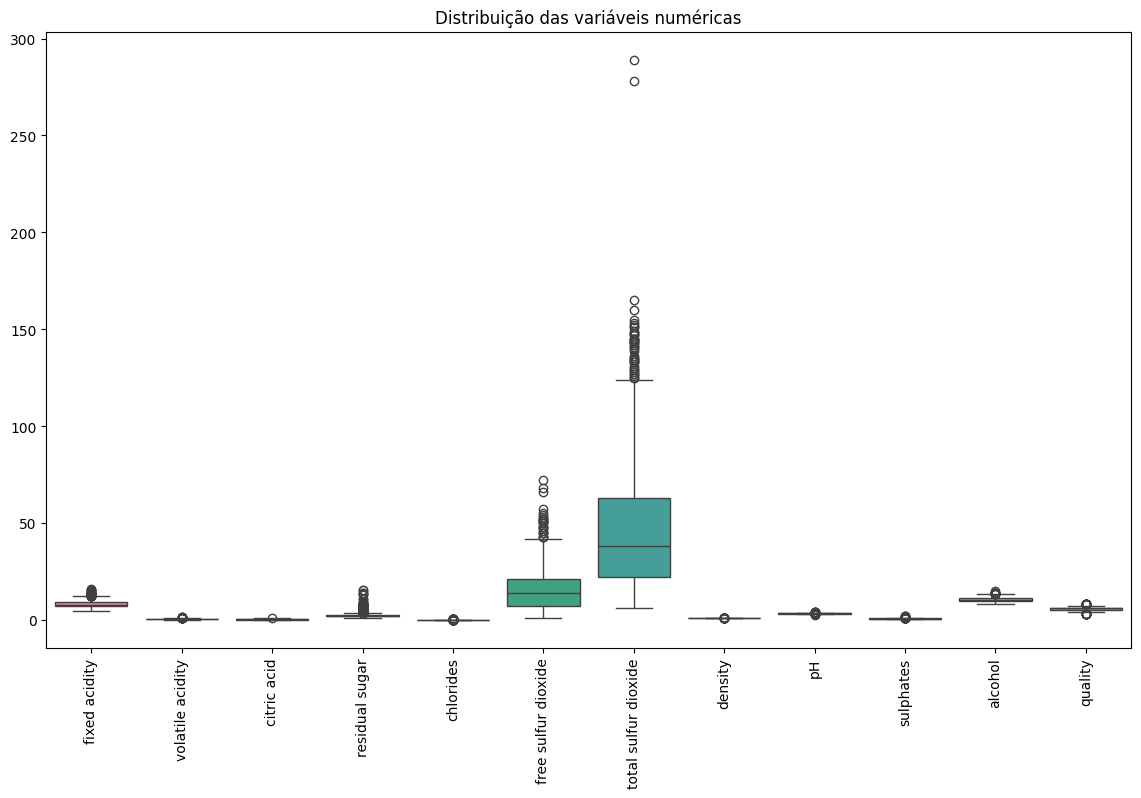

In [9]:
# Verificando possíveis outliers nas variáveis numéricas
plt.figure(figsize=(14, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Distribuição das variáveis numéricas')
plt.show()

In [10]:
# Verificando o balanceamento da variável target
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

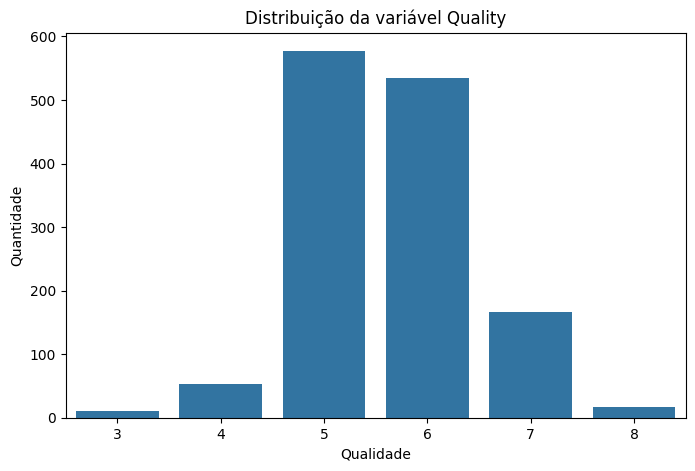

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='quality')
plt.title('Distribuição da variável Quality')
plt.xlabel('Qualidade')
plt.ylabel('Quantidade')
plt.show()

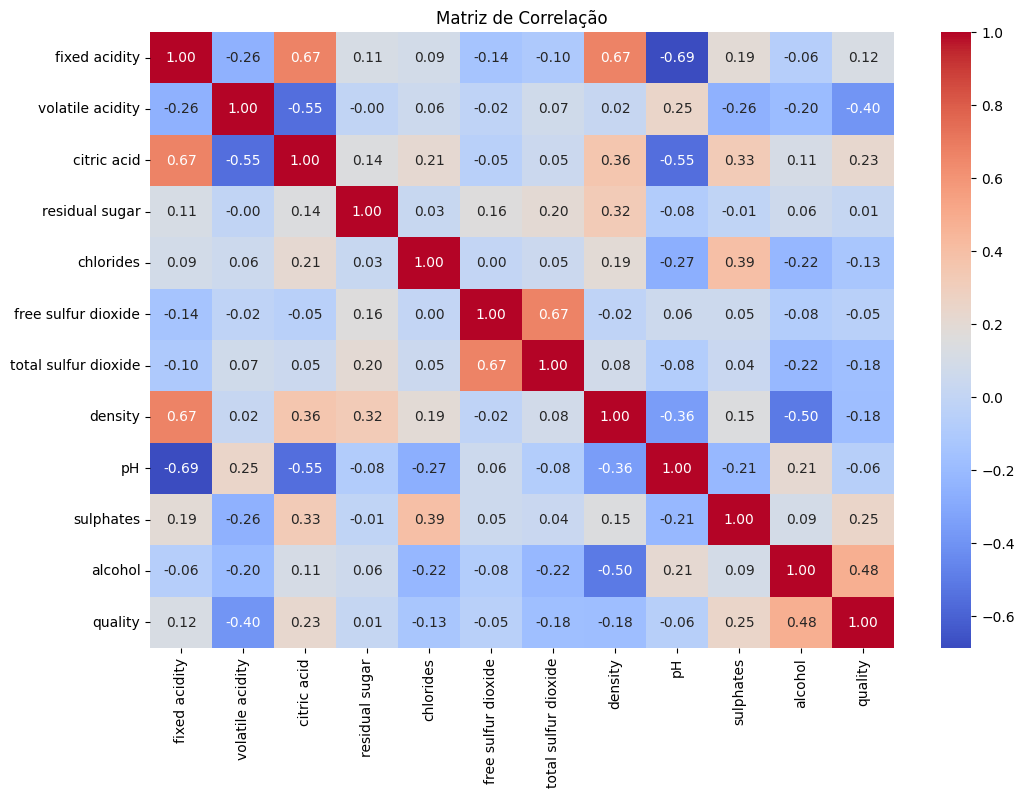

In [12]:
# Calculando a matriz de correlação
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

In [13]:
# Correlação das variáveis com a target quality
corr_quality = corr['quality'].drop('quality').sort_values(ascending=False)

corr_quality

alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

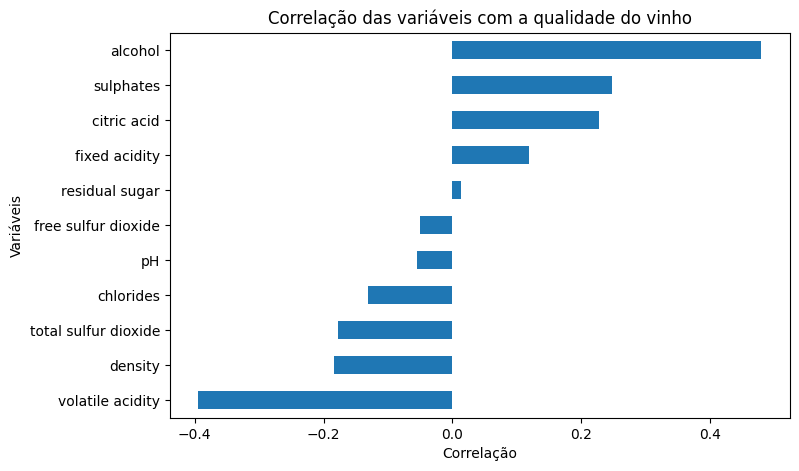

In [14]:
# Gráfico das correlações com a variável target
plt.figure(figsize=(8, 5))
corr_quality.sort_values().plot(kind='barh')
plt.title('Correlação das variáveis com a qualidade do vinho')
plt.xlabel('Correlação')
plt.ylabel('Variáveis')
plt.show()

In [15]:
# Selecionando variáveis com maior correlação positiva ou negativa com a target
selected_variables = corr_quality[abs(corr_quality) >= 0.20].index.tolist()

selected_variables

['alcohol', 'sulphates', 'citric acid', 'volatile acidity']

In [16]:
# Criando um novo dataframe apenas com as variáveis mais correlacionadas e a target
df_model = df[selected_variables + ['quality']]

df_model.head()

,alcohol,sulphates,citric acid,volatile acidity,quality
0,9.4,0.56,0.00,0.70,5
1,9.8,0.68,0.00,0.88,5
2,9.8,0.65,0.04,0.76,5
3,9.8,0.58,0.56,0.28,6
5,9.4,0.56,0.00,0.66,5


A análise descritiva da base permitiu observar a distribuição das variáveis numéricas, suas medidas de tendência central e dispersão, além de indicar a presença de possíveis outliers em algumas variáveis.

O boxplot mostrou que algumas features apresentam valores discrepantes, principalmente em variáveis como free sulfur dioxide, total sulfur dioxide e residual sugar. No entanto, esses valores não foram removidos neste momento, pois podem representar características reais da base e o algoritmo Random Forest tende a ser mais robusto em relação à presença de outliers.

Também foi analisada a distribuição da variável target, quality. Verificou-se que a base é desbalanceada, com maior concentração de observações nas classes 5 e 6, enquanto as classes 3, 4 e 8 apresentam bem menos exemplos. Esse desbalanceamento pode dificultar a capacidade do modelo em prever corretamente as classes minoritárias.

Na análise de correlação com a variável target, observou-se que as variáveis com maior relação com a qualidade do vinho foram:

- alcohol: correlação positiva de aproximadamente 0.48;
- sulphates: correlação positiva de aproximadamente 0.25;
- citric acid: correlação positiva de aproximadamente 0.23;
- volatile acidity: correlação negativa de aproximadamente -0.40.

Com base nisso, foi criado um novo dataframe contendo apenas essas variáveis mais relacionadas com a target, além da variável quality, para ser utilizado na modelagem.

## 4 Preparação Final dos Dados

In [17]:
# Separando a base em X(features) e y(target)
X = df_model.drop('quality', axis=1)
y = df_model['quality']

In [18]:
# Separando a base em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [19]:
print('Tamanho da base de treino:', X_train.shape)
print('Tamanho da base de teste:', X_test.shape)

Tamanho da base de treino: (1087, 4)
Tamanho da base de teste: (272, 4)


Para a preparação final dos dados, a base foi separada em variáveis explicativas (X) e variável alvo (y). Em seguida, os dados foram divididos em conjunto de treino e teste, utilizando 80% das observações para treinamento e 20% para teste.

Essa divisão é importante para que o modelo seja treinado em uma parte da base e posteriormente avaliado em dados não vistos, permitindo analisar sua capacidade de generalização.

## 5 Modelagem

In [20]:
# Iniciando o modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Treinando o modelo
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
# Fazendo previsões no conjunto de teste
y_pred = rf_model.predict(X_test)

Foi utilizado o algoritmo Random Forest Classifier para a construção do modelo de classificação. Esse algoritmo é baseado em múltiplas árvores de decisão, combinando seus resultados para produzir uma previsão final mais robusta.

O modelo foi treinado com as variáveis selecionadas a partir da análise de correlação: alcohol, sulphates, citric acid e volatile acidity.

## 6 Avaliação

In [22]:
# Avaliando o modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Acurácia: {accuracy:.2f}')
print('Relatório de Classificação:\n', report)
print('Matriz de Confusão:\n', conf_matrix)

Acurácia: 0.56
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.33      0.09      0.14        11
           5       0.62      0.66      0.64       116
           6       0.51      0.59      0.55       107
           7       0.48      0.30      0.37        33
           8       0.00      0.00      0.00         3

    accuracy                           0.56       272
   macro avg       0.32      0.27      0.28       272
weighted avg       0.54      0.56      0.54       272

Matriz de Confusão:
 [[ 0  1  1  0  0  0]
 [ 0  1  7  3  0  0]
 [ 0  1 77 35  3  0]
 [ 0  0 37 63  7  0]
 [ 0  0  2 21 10  0]
 [ 0  0  0  2  1  0]]


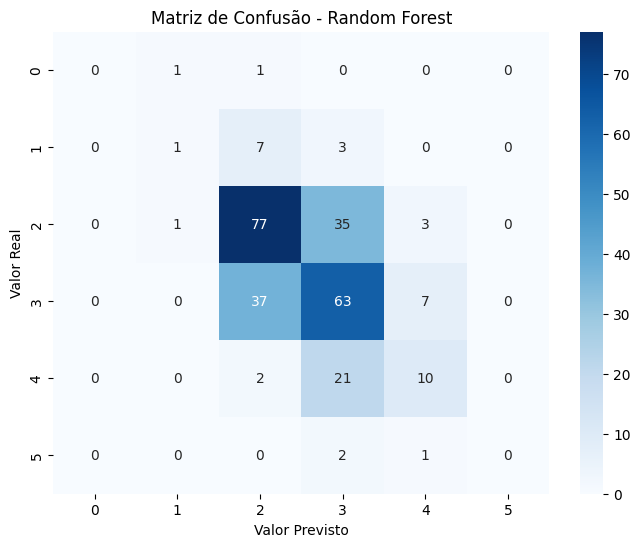

In [23]:
# Visualizando a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Valor Previsto')
plt.ylabel('Valor Real')
plt.show()

In [24]:
# Verificando a importância das variáveis no modelo
importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': rf_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

importance

,Variável,Importância
0,alcohol,0.287991
3,volatile acidity,0.253824
1,sulphates,0.239942
2,citric acid,0.218243


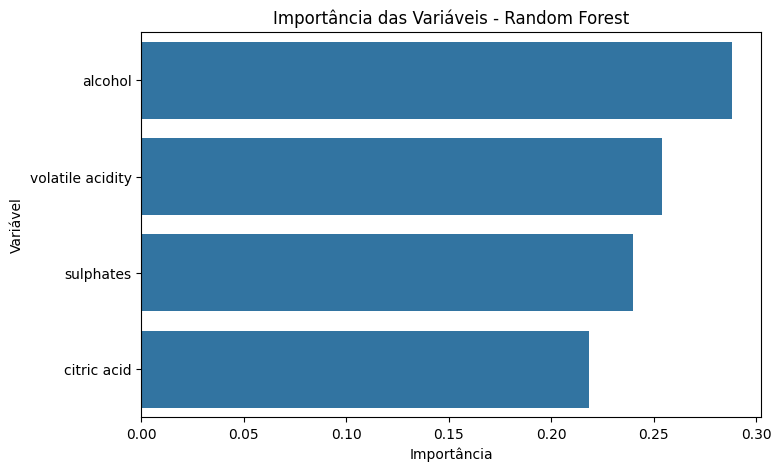

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='Importância', y='Variável')
plt.title('Importância das Variáveis - Random Forest')
plt.show()

O modelo inicial foi avaliado por meio da acurácia, do relatório de classificação e da matriz de confusão.

A acurácia obtida pelo modelo inicial foi de 0.56, indicando que o modelo acertou aproximadamente 56% das previsões no conjunto de teste. Ao observar o relatório de classificação, nota-se que o desempenho foi melhor nas classes mais frequentes, especialmente nas classes 5 e 6.

Em contrapartida, o modelo apresentou grande dificuldade em prever corretamente as classes 3, 4 e 8, que possuem pouca representatividade na base. Isso pode ser explicado pelo desbalanceamento da variável target, já que o algoritmo tende a aprender melhor os padrões das classes com maior número de exemplos.

A matriz de confusão também reforça essa interpretação, mostrando maior concentração de acertos nas classes intermediárias e maior confusão entre categorias próximas de qualidade.

## 7 Melhorando os Hiperparâmetros

In [26]:
# Definindo o espaço de busca dos hiperparâmetros
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

# Criando o modelo base para o RandomizedSearchCV
rf_model_search = RandomForestClassifier(random_state=42)

# Executando o Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_model_search,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [27]:
# Obtendo os melhores hiperparâmetros
best_params = random_search.best_params_

print(f'Melhores Hiperparâmetros: {best_params}')

Melhores Hiperparâmetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'class_weight': None}


In [28]:
# Treinando o modelo com os melhores hiperparâmetros encontrados
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [29]:
# Fazendo novas previsões
y_pred_best = best_rf_model.predict(X_test)

In [30]:
# Avaliando o modelo otimizado
accuracy_best = accuracy_score(y_test, y_pred_best)
report_best = classification_report(y_test, y_pred_best, zero_division=0)
conf_matrix_best = confusion_matrix(y_test, y_pred_best)

print(f'Acurácia do modelo inicial: {accuracy:.2f}')
print(f'Acurácia do modelo otimizado: {accuracy_best:.2f}')
print('Relatório de Classificação:\n', report_best)
print('Matriz de Confusão:\n', conf_matrix_best)

Acurácia do modelo inicial: 0.56
Acurácia do modelo otimizado: 0.58
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.63      0.73      0.68       116
           6       0.52      0.60      0.56       107
           7       0.53      0.24      0.33        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.28      0.26      0.26       272
weighted avg       0.54      0.58      0.55       272

Matriz de Confusão:
 [[ 0  0  1  1  0  0]
 [ 0  0  8  3  0  0]
 [ 0  0 85 30  1  0]
 [ 0  0 38 64  5  0]
 [ 0  0  2 23  8  0]
 [ 0  0  0  2  1  0]]


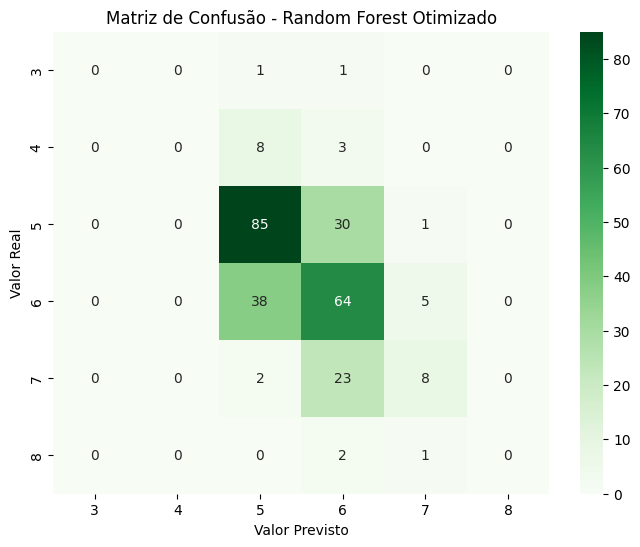

In [31]:
labels = sorted(y_test.unique())

# Visualizando a matriz de confusão do modelo otimizado
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão - Random Forest Otimizado')
plt.xlabel('Valor Previsto')
plt.ylabel('Valor Real')
plt.show()

Após a otimização dos hiperparâmetros com RandomizedSearchCV, a acurácia do modelo passou de 0.56 para 0.58. A melhoria foi pequena, mas indica que o ajuste dos parâmetros contribuiu para encontrar uma configuração um pouco melhor para o modelo.

Apesar da melhora, o modelo ainda apresentou dificuldade para prever as classes com menor quantidade de registros, principalmente as classes 3, 4 e 8. Isso mostra que o principal desafio da base está relacionado ao desbalanceamento da variável target.

## 8 Chegando a perfeição

Para melhorar ainda mais as previsões, poderiam ser aplicadas outras técnicas, como balanceamento das classes com métodos como SMOTE ou undersampling, já que a variável quality apresenta desbalanceamento e possui poucas amostras nas classes 3, 4 e 8.

Também seria interessante testar o modelo utilizando todas as variáveis da base, pois o Random Forest consegue lidar bem com várias features e pode capturar relações não lineares que a correlação simples não mostra.

Além disso, poderiam ser avaliados outros algoritmos de classificação, como Gradient Boosting, XGBoost ou SVM, além de realizar uma validação cruzada mais robusta e uma análise mais detalhada dos erros nas classes minoritárias.